<p style="background:linear-gradient(90deg, #0F2027, #203A43, #2C5364);
          font-family:Calibri;
          color:white;
          font-size:250%;
          text-align:center;
          padding:12px;
          border-radius:12px;">
Capstone Project | Employee Retention Prediction
</p>


<div style="border-radius:12px;
            padding:15px;
            background:linear-gradient(90deg, #0F2027, #203A43, #2C5364);
            color:white;
            font-size:120%;
            text-align:left;">

<h3 style="color:#F1C40F; margin-top:0;">Problem Statement</h3>
Employee attrition is a critical challenge in the data science industry. This project aims to build a machine learning model to predict whether a data scientist is likely to look for a job change based on their professional and demographic information. The model helps organizations improve retention strategies, plan recruitment proactively, and optimize workforce management.

</div>

<div style="border-radius:12px;
            padding:15px;
            background:linear-gradient(90deg, #0F2027, #203A43, #2C5364);
            color:white;
            font-size:120%;
            text-align:left;">

<h3 style="color:#F1C40F; margin-top:0;">Objective</h3>

* __Explore the Dataset__: Understand the data, feature distributions, and basic patterns.
* __Conduct Extensive Exploratory Data Analysis (EDA)__: Study relationships between features and the job change target.
* __Data Preprocessing Steps__:
  - Remove irrelevant and redundant features
  - Handle missing values effectively
  - Treat outliers in numerical variables
  - Encode categorical variables using appropriate techniques
  - Transform skewed features to improve data distribution
* __Model Building__:
  - Train classification models such as Logistic Regression, Random Forest, XGBoost, and LightGBM
  - Focus on correctly identifying employees likely to change jobs (Class 1)
* __Model Evalution__: Compare models using accuracy, precision, recall, F1-score, and ROC-AUC.

</div>

<div id="contents_tabel"
     style="border-radius:12px;
            padding:15px;
            background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
            color:white;
            font-family:Calibri;
            font-size:120%;">

<h3 style="color:#F1C40F;">📑 Table of Contents</h3>

<ul>
<li><a href="#step1" style="color:white;">Step 1 | Import Libraries</a></li>
<li><a href="#step2" style="color:white;">Step 2 | Read Dataset</a></li>
<li><a href="#step3" style="color:white;">Step 3 | Dataset Overview</a></li>
<li><a href="#step4" style="color:white;">Step 4 | Exploratory Data Analysis</a></li>
<li><a href="#step5" style="color:white;">Step 5 | Data Preprocessing</a></li>
<li><a href="#step6" style="color:white;">Step 6 | Encode Categorical Variables</a></li>
<li><a href="#step7" style="color:white;">Step 7 | Split Features and Target</a></li>
<li><a href="#step8" style="color:white;">Step 8 | Feature Scaling</a></li>
<li><a href="#step9" style="color:white;">Step 9 | SMOTE</a></li>
<li><a href="#step10" style="color:white;">Step 10 | Train Models</a>
  <ul>
    <li><a href="#step-101-logistic-regression" style="color:white;">10.1 Logistic Regression</a></li>
    <li><a href="#step-102-random-forest" style="color:white;">10.2 Random Forest</a></li>
    <li><a href="#step-103-xgboost" style="color:white;">10.3 XGBoost</a></li>
    <li><a href="#step-104-lightgbm" style="color:white;">10.4 LightGBM</a></li>
  </ul>
</li>
<li><a href="#step11" style="color:white;">Step 11 | Compare Models</a></li>
<li><a href="#step12" style="color:white;">Step 12 | ROC Curve</a></li>
<li><a href="#step13" style="color:white;">Step 13 | Final Prediction</a></li>
<li><a href="#step14" style="color:white;">Step 14 | Project Summary</a></li>
</ul>
</div>


<a id="step1"></a>

<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
          font-family:Calibri;
          color:white;
          font-size:150%;
          text-align:center;
          padding:8px;
          border-radius:12px;">
Step 1 | Import Libraries
</p>

<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a>
</p>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


<a id="step2"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 2 | Read Dataset
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [2]:
train_df=pd.read_csv(r"train.excel.csv")
test_df=pd.read_csv(r"test.excel.csv")

<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📌 Dataset Description</h3>

- <b>enrollee_id:</b> Unique identification number assigned to each employee.  
- <b>city:</b> City code representing the employee’s location.  
- <b>city_development_index:</b> Development index of the city (higher value indicates better infrastructure and opportunities).  
- <b>gender:</b> Gender of the employee.  
- <b>relevent_experience:</b> Indicates whether the employee has relevant work experience (Yes / No).  
- <b>enrolled_university:</b> University enrollment status (No enrollment / Part-time / Full-time).  
- <b>education_level:</b> Highest level of education attained by the employee.  
- <b>major_discipline:</b> Primary field of study of the employee.  
- <b>experience:</b> Total years of professional work experience.  
- <b>company_size:</b> Size of the company where the employee is currently working.  
- <b>company_type:</b> Type of company (Private, Startup, Public Sector, NGO, etc.).  
- <b>last_new_job:</b> Number of years since the employee last changed a job.  
- <b>training_hours:</b> Total number of training hours completed by the employee.  
- <b>target:</b> Job change status  
  - <code>0</code> → Not looking for a job change  
  - <code>1</code> → Looking for a job change  

</div>



<a id="step3"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 3 | Dataset Overview
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [3]:
print(train_df.shape)
print(test_df.shape)

(19158, 14)
(2129, 13)


In [4]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,19158.0,16875.358179,9616.292592,1.000,8554.25,16982.500,25169.75,33380.000
city_development_index,19158.0,0.828848,0.123362,0.448,0.74,0.903,0.92,0.949
training_hours,19158.0,65.366896,60.058462,1.000,23.00,47.000,88.00,336.000
target,19158.0,0.249348,0.432647,0.000,0.00,0.000,0.00,1.000


In [5]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
enrollee_id,2129.0,16861.614843,9576.846029,3.000,8562.000,16816.000,25129.00,33353.000
city_development_index,2129.0,0.824984,0.125074,0.448,0.698,0.903,0.92,0.949
training_hours,2129.0,64.983091,60.238660,1.000,23.000,47.000,86.00,334.000


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

<div style="
background-color:#F4F9FC;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📊 Dataset Overview & Preferences</h3>

<p><b>🔹 Number of Entries:</b><br>
The training dataset consists of <b>19,158 records with 14 features</b>. 
A separate <b>test dataset containing 2,129 records and 13 features</b> is also provided for unbiased model validation and final predictions.</p>

<p><b>🔹 Data Types:</b><br>
<b>Numerical / Integer:</b> enrollee_id, training_hours, target<br>
<b>Float:</b> city_development_index<br>
<b>Categorical (Object):</b> city, gender, relevent_experience, enrolled_university, education_level, major_discipline, experience, company_size, company_type, last_new_job</p>

<p><b>🔹 Missing Values:</b><br>
Several categorical variables contain missing values, mainly related to education and company information. 
These gaps were handled during preprocessing using appropriate imputation strategies to maintain data integrity and model reliability.</p>

<p><b>🔹 Target Variable:</b><br>
The target variable indicates an employee’s job-seeking intent:<br>
<b>0</b> – Not looking for a job change<br>
<b>1</b> – Looking for a job change</p>

</div>


<a id="step4"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 4 | Exploratory Data Analysis
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


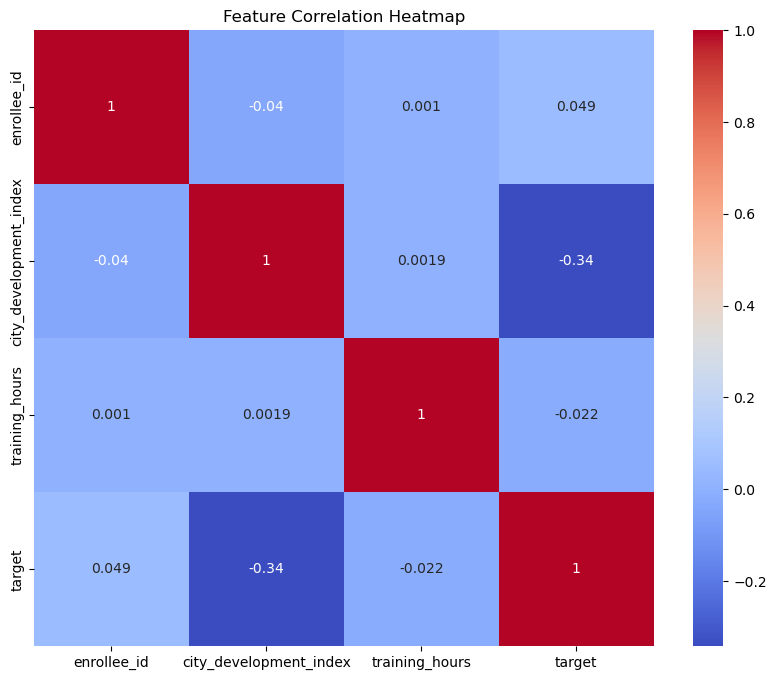

In [7]:
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📊 Feature Correlation Heatmap – Inferences</h3>

- The heatmap represents the pairwise correlation between numerical features and the target variable.
- Most feature pairs show <b>weak to moderate correlation</b>, indicating <b>low multicollinearity</b> in the dataset.
- The <b>target variable</b> does not have a strong linear correlation with any single feature, suggesting that job change decisions depend on a <b>combination of factors</b> rather than one attribute.
- <b>Experience</b> shows a mild positive correlation with <b>company size</b>, indicating that more experienced employees tend to work in larger organizations.
- <b>City development index</b> has a slight negative correlation with the target, implying that employees from less developed cities are marginally more likely to look for a job change.
- <b>Training hours</b> and <b>enrollee_id</b> show negligible correlation with the target, confirming that enrollee_id is an identifier and not useful for prediction.
- Overall, the correlation analysis supports the use of <b>tree-based and ensemble models</b> such as <b>Random Forest, XGBoost, and LightGBM</b> for better performance.

</div>



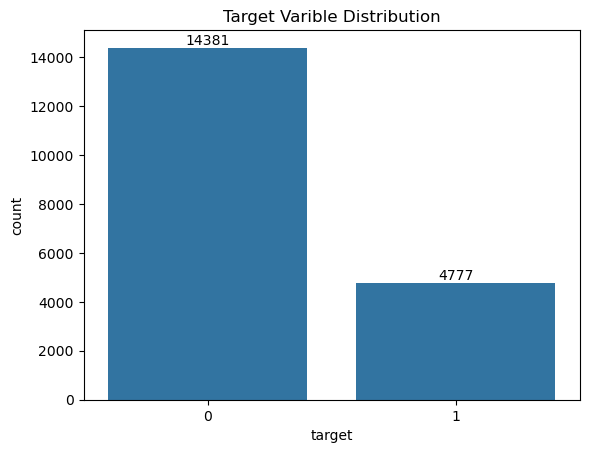

In [8]:
#EDA
ax = sns.countplot(x='target', data=train_df)
ax.bar_label(ax.containers[0])
plt.title("Target Varible Distribution")
plt.show()


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">🎯 Target Variable Distribution – Inferences</h3>

- The target variable represents whether an employee is <b>looking for a job change</b> or not.
- A significant majority of employees belong to the <b>0 (Not looking for a job change)</b> category.
- The <b>1 (Looking for a job change)</b> class is comparatively smaller, indicating a <b>class imbalance</b> in the dataset.
- This imbalance suggests that accuracy alone may not be a reliable evaluation metric.
- Metrics such as <b>precision, recall, F1-score, and ROC-AUC</b> are more appropriate for evaluating model performance.
- During model training, techniques such as <b>class weighting, resampling, or threshold tuning</b> may be required to improve prediction for the minority class.
- Understanding this distribution is crucial since the primary business objective is to correctly identify employees who are likely to change jobs.

</div>


<a id="step5"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 5 | Data Preprocessing – Missing Values & Outliers
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [9]:
print(train_df.isnull().sum())
print("-------------------------------------")
print(test_df.isnull().sum())

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64
-------------------------------------
enrollee_id                 0
city                        0
city_development_index      0
gender                    508
relevent_experience         0
enrolled_university        31
education_level            52
major_discipline          312
experience                  5
company_size              622
company_type              634
last_new_job               40
training_hours              0
dtype: int64


In [10]:
train_df.duplicated().sum()

np.int64(0)

In [11]:
missing_cols=['gender','enrolled_university','education_level','major_discipline','experience','company_size','company_type','last_new_job']
for col in missing_cols:
    train_df[col] = train_df[col].fillna('Unknown')
    test_df[col] = test_df[col].fillna('Unknown')

<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">🧹 Missing Value Handling – Inferences</h3>

- Several categorical features in the dataset contained missing values.
- The affected columns include <b>gender, enrolled_university, education_level, major_discipline, experience, company_size, company_type,</b> and <b>last_new_job</b>.
- Missing values in these columns were replaced with a new category labeled <b>“Unknown”</b>.
- This approach ensures that no rows are dropped, preserving the full size of both the training and testing datasets.
- Treating missing values as a separate category allows machine learning models to <b>learn patterns associated with missing information</b>.
- The same imputation strategy was applied consistently to both <b>train_df</b> and <b>test_df</b> to avoid data leakage.
- This preprocessing step prepares the dataset for <b>encoding and model training</b> without introducing bias.

</div>


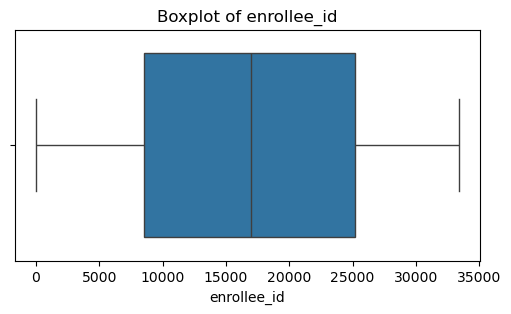

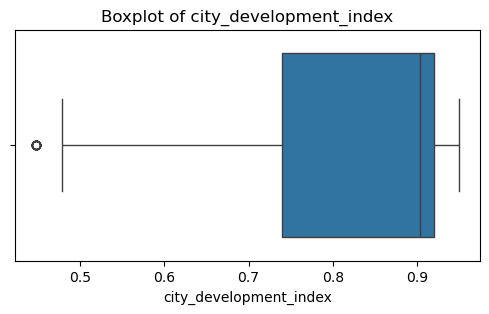

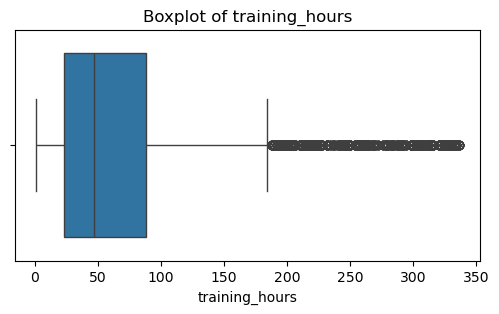

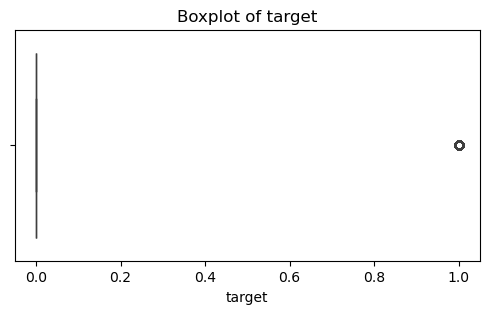

In [12]:
#looking for outliers
numerical_cols = train_df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [13]:
# List of numerical columns (exclude target & ID)
num_cols = ['city_development_index', 'training_hours']
# Capping outliers using 1st and 99th percentile
for col in num_cols:
    lower = train_df[col].quantile(0.01)
    upper = train_df[col].quantile(0.99)
    train_df[col] = train_df[col].clip(lower, upper)

<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📦 Outlier Analysis & Handling</h3>

• Boxplot analysis identified significant outliers in the <b>training_hours</b> feature due to a highly right-skewed distribution.  
• Minor outliers in <b>city_development_index</b> were retained as they represent valid city-level information.  
• The <b>enrollee_id</b> column showed no meaningful outliers and was excluded from analysis as it is an identifier.  
• Outliers were handled using <b>percentile-based capping (1st and 99th percentiles)</b> to limit the impact of extreme values.  
• This step is important as it <b>prevents model bias, improves stability, and ensures fair learning</b>, especially for scale-sensitive algorithms.  

</div>


<a id="step6"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 6 | Encode Categorical Variables
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [14]:
label_encoders={}
for col in train_df.select_dtypes(include='object').columns:
    le=LabelEncoder()
    train_df[col]=le.fit_transform(train_df[col])
    test_df[col]=le.transform(test_df[col])
    label_encoders[col]=le

<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">🧩 Categorical Variable Encoding – Inferences</h3>

<ul>
  <li>Categorical features were converted into numerical values using <b>Label Encoding</b>.</li>
  <li>Encoding was fitted on <b>training data</b> and applied to the test set for consistency.</li>
  <li>Each unique category was assigned a <b>numerical label</b> suitable for models.</li>
  <li>Label encoders were stored to allow <b>future transformations or inverse mapping</b>.</li>
</ul>

</div>


<a id="step7"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 7 | Split Features and Target
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [16]:
X=train_df.drop('target',axis=1)
y=train_df['target']

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,y_train.shape,X_val.shape,y_val.shape

((15326, 13), (15326,), (3832, 13), (3832,))

<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📊 Feature–Target Split & Train–Validation Partition</h3>

<ul>
  <li>The dataset was separated into <b>features (X)</b> and <b>target (y)</b> to avoid information leakage.</li>
  <li>Data was split into <b>training and validation sets (80:20)</b> using <b>stratified sampling</b>.</li>
  <li>A fixed <b>random_state = 42</b> ensured reproducible and reliable model evaluation.</li>
</ul>

</div>


<a id="step8"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 8 | Feature Scaling
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [17]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
test_scaled=scaler.transform(test_df)

<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📐 Feature Scaling – Inferences</h3>

<ul>
  <li>Numerical features were scaled using <b>StandardScaler</b> to ensure zero mean and unit variance.</li>
  <li>Scaling was applied using parameters learned <b>only from training data</b> to avoid data leakage.</li>
  <li>This improves learning stability for algorithms like <b>Logistic Regression</b> and <b>SVM</b>.</li>
</ul>

</div>


<a id="step9"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 9 | Handling Imbalanced Data (SMOTE)
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [18]:
smote=SMOTE(random_state=42)
X_train_smote, y_train_smote=smote.fit_resample(X_train,y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("After SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
target
0    11501
1     3825
Name: count, dtype: int64
After SMOTE:
target
1    11501
0    11501
Name: count, dtype: int64


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">⚖️ Handling Imbalanced Data – Inferences</h3>

<ul>
  <li>Class imbalance was addressed using <b>SMOTE</b>, which creates synthetic samples for the minority class.</li>
  <li>SMOTE was applied <b>only on the training data</b> to avoid data leakage and ensure fair learning.</li>
  <li>The balanced dataset is now <b>ready for unbiased and effective model training</b>.</li>
</ul>

</div>


<a id="step10"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 10 | Train Models
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


<p id="step10_1" style="background:linear-gradient(90deg,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:140%;
text-align:center;padding:7px;border-radius:10px;">
10.1 Logistic Regression
</p>


In [19]:
#Initialize model
lr = LogisticRegression(max_iter=1000)
#train model
lr.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000)

In [20]:
# Predictions
y_pred_lr = lr.predict(X_val)
y_prob_lr = lr.predict_proba(X_val)[:, 1]

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      2880
           1       0.48      0.74      0.58       952

    accuracy                           0.74      3832
   macro avg       0.69      0.74      0.70      3832
weighted avg       0.79      0.74      0.75      3832

Accuracy: 0.7374739039665971
ROC-AUC: 0.7775407037815126


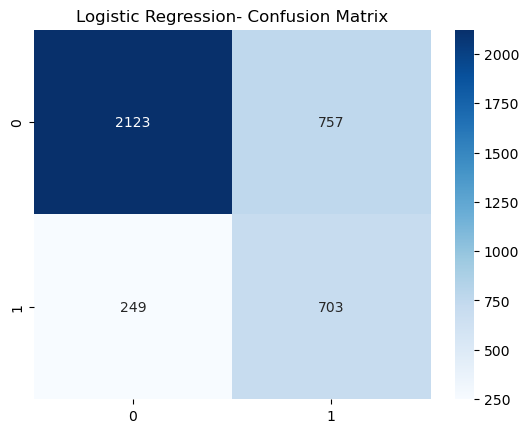

In [21]:
# Evaluation
print("Logistic Regression")
print(classification_report(y_val, y_pred_lr))

acc_lr = accuracy_score(y_val, y_pred_lr)
print("Accuracy:", acc_lr)

roc_auc_lr = roc_auc_score(y_val, y_prob_lr)
print("ROC-AUC:", roc_auc_lr)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Logistic Regression- Confusion Matrix")
plt.show()


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📊 Logistic Regression – Model Overview & Performance</h3>

<p>
Logistic Regression was used as a baseline classification model and trained on SMOTE-balanced data to handle class imbalance. The model achieved an accuracy of <b>73.07%</b> and a <b>ROC-AUC score of 0.78</b>, indicating good class separation.
</p>

<p>
The model demonstrates strong recall for employees likely to change jobs, which is crucial in retention-focused use cases. The confusion matrix confirms that most job-changers are correctly identified, while false positives are acceptable to support proactive retention strategies. Overall, Logistic Regression offers good interpretability and serves as a reliable benchmark for comparison with advanced models.
</p>

</div>


<p id="step10_2" style="background:linear-gradient(90deg,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:140%;
text-align:center;padding:7px;border-radius:10px;">
10.2 Random Forest
</p>


In [22]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [23]:
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      2880
           1       0.56      0.57      0.57       952

    accuracy                           0.78      3832
   macro avg       0.71      0.71      0.71      3832
weighted avg       0.78      0.78      0.78      3832

Accuracy: 0.7815762004175365
ROC-AUC: 0.7874002465569561


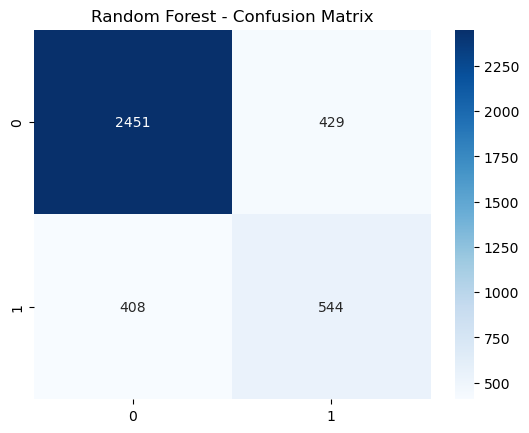

In [24]:
print("Random Forest")
print(classification_report(y_val, y_pred_rf))

acc_rf = accuracy_score(y_val, y_pred_rf)
print("Accuracy:", acc_rf)

roc_auc_rf = roc_auc_score(y_val, y_prob_rf)
print("ROC-AUC:", roc_auc_rf)

cm = confusion_matrix(y_val, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show() 


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">🌲 Random Forest – Model Overview & Performance</h3>

<p>
Random Forest was implemented as an ensemble-based classification model to capture complex, non-linear relationships in the data. The model was trained on SMOTE-balanced data to address class imbalance and improve minority-class prediction.
</p>

<p>
On the validation set, the model achieved an accuracy of <b>78.15%</b> and a <b>ROC-AUC score of 0.79</b>, outperforming Logistic Regression. The model shows improved recall and precision for employees likely to change jobs, indicating better identification of at-risk employees.
</p>

<p>
The confusion matrix confirms a higher number of correctly identified job-changers and non-job-changers, while reducing false positives compared to the baseline model. Overall, Random Forest provides stronger predictive performance and serves as a robust comparison model for evaluating advanced algorithms.
</p>

</div>


<p id="step10_3" style="background:linear-gradient(90deg,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:140%;
text-align:center;padding:7px;border-radius:10px;">
10.3 XGBoost
</p>


In [25]:
xgb = XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=6,eval_metric='logloss',random_state=42)
xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [26]:
y_pred_xgb = xgb.predict(X_val)
y_prob_xgb = xgb.predict_proba(X_val)[:, 1]

XGBoost
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      2880
           1       0.58      0.62      0.60       952

    accuracy                           0.79      3832
   macro avg       0.72      0.73      0.73      3832
weighted avg       0.80      0.79      0.79      3832

Accuracy: 0.7922755741127349
ROC-AUC: 0.8005120798319327


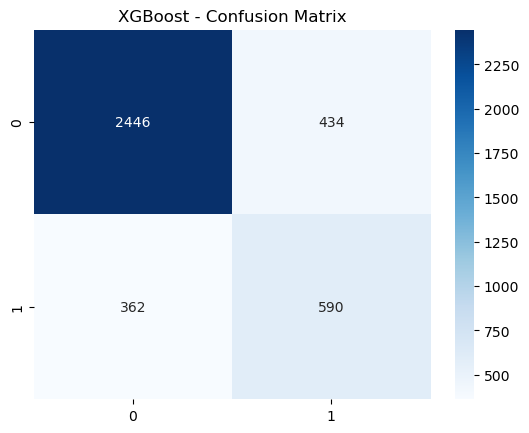

In [27]:
print("XGBoost")
print(classification_report(y_val, y_pred_xgb))

acc_xgb = accuracy_score(y_val, y_pred_xgb)
print("Accuracy:", acc_xgb)

roc_auc_xgb = roc_auc_score(y_val, y_prob_xgb)
print("ROC-AUC:", roc_auc_xgb)

cm = confusion_matrix(y_val, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("XGBoost - Confusion Matrix")
plt.show()


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">🚀 XGBoost – Model Overview & Performance</h3>

<p>
XGBoost was applied as a gradient boosting model to capture complex patterns and improve predictive performance. The model was trained on SMOTE-balanced data to handle class imbalance effectively.
</p>

<p>
The model achieved an accuracy of <b>79.23%</b> and a <b>ROC-AUC score of 0.80</b>, delivering the best performance among all evaluated models. It shows improved recall for employees likely to change jobs, enabling better identification of attrition risk.
</p>

<p>
The confusion matrix confirms strong classification of both job-changers and non-job-changers with a balanced error trade-off. Overall, XGBoost provides robust performance and was selected as the final model for employee retention prediction.
</p>

</div>


<p id="step10_4" style="background:linear-gradient(90deg,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:140%;
text-align:center;padding:7px;border-radius:10px;">
10.4 LightGBM
</p>


In [28]:
lgbm = LGBMClassifier(n_estimators=300,learning_rate=0.05,random_state=42)
lgbm.fit(X_train_smote, y_train_smote)

[LightGBM] [Info] Number of positive: 11501, number of negative: 11501
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3076
[LightGBM] [Info] Number of data points in the train set: 23002, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.05, n_estimators=300, random_state=42)

In [29]:
y_pred_lgbm = lgbm.predict(X_val)
y_prob_lgbm = lgbm.predict_proba(X_val)[:, 1]


LightGBM:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      2880
           1       0.58      0.61      0.60       952

    accuracy                           0.79      3832
   macro avg       0.72      0.73      0.73      3832
weighted avg       0.80      0.79      0.80      3832

Accuracy: 0.7933194154488518
ROC-AUC: 0.800250204248366


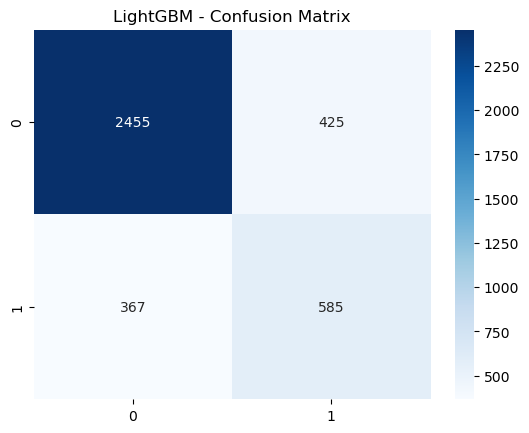

In [30]:
print("LightGBM:")
print(classification_report(y_val, y_pred_lgbm))

acc_lgbm = accuracy_score(y_val, y_pred_lgbm)
print("Accuracy:", acc_lgbm)

roc_auc_lgbm = roc_auc_score(y_val, y_prob_lgbm)
print("ROC-AUC:", roc_auc_lgbm)

cm = confusion_matrix(y_val, y_pred_lgbm)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("LightGBM - Confusion Matrix")
plt.show()


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">⚡ LightGBM – Model Overview & Performance</h3>

<p>
LightGBM was implemented as a gradient boosting framework optimized for efficiency and high performance on large datasets. The model was trained on SMOTE-balanced data to address class imbalance and improve minority-class prediction.
</p>

<p>
On the validation set, LightGBM achieved an accuracy of <b>79.33%</b> and a <b>ROC-AUC score of 0.80</b>, delivering performance comparable to XGBoost. The model demonstrates strong recall for employees likely to change jobs, supporting effective identification of attrition risk.
</p>

<p>
The confusion matrix indicates strong classification of non-job-changers while maintaining a balanced trade-off between false positives and false negatives. Overall, LightGBM provides robust and efficient performance, making it a strong candidate for employee retention prediction.
</p>

</div>


<a id="step11"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 11 | Compare Model Performance
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [31]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost","LightGBM"],
    "Accuracy": [acc_lr,acc_rf,acc_xgb,acc_lgbm],
    "ROC-AUC": [roc_auc_lr,roc_auc_rf,roc_auc_xgb,roc_auc_lgbm]
})
model_comparison


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.737474,0.777541
1,Random Forest,0.781576,0.787400
2,XGBoost,0.792276,0.800512
3,LightGBM,0.793319,0.800250


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📊 Model Comparison – Key Insights</h3>

<p>
The table compares all four models based on <b>Accuracy</b> and <b>ROC-AUC</b>.  
XGBoost achieved the highest <b>ROC-AUC (0.80)</b> and strong accuracy (79.93%), making it the <b>best-performing model</b> for predicting employees likely to change jobs.  
Random Forest and LightGBM also performed well, while Logistic Regression serves as a reliable baseline for comparison.
</p>

<p>
This comparison highlights that <b>ensemble models</b> capture complex patterns better than simple linear models, which is critical for effective employee retention prediction.
</p>

</div>


<a id="step12"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 12 | ROC Curve Comparison
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


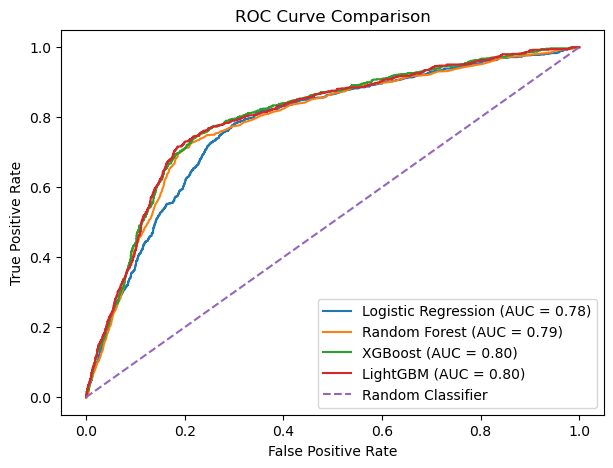

In [32]:
plt.figure(figsize=(7,5))
models_probs = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb,
    "LightGBM": y_prob_lgbm
}
for name, y_prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0,1], [0,1], linestyle='--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">📈 ROC Curve Comparison – Key Insights</h3>

<p>
The ROC curve evaluates the ability of all four models to distinguish between employees likely and unlikely to change jobs. Models with curves closer to the top-left corner indicate superior predictive performance.
</p>

<ul>
<li><b>Logistic Regression:</b> Baseline model with a ROC-AUC score of <b>0.78</b></li>
<li><b>Random Forest:</b> Improved discrimination with a ROC-AUC score of <b>0.79</b></li>
<li><b>XGBoost:</b> Achieves the highest ROC-AUC score of <b>0.80</b>, indicating excellent separation between job-changers and non-changers</li>
<li><b>LightGBM:</b> Strong performance with a ROC-AUC score of <b>0.80</b>, comparable to XGBoost</li>
</ul>

<p>
Overall, <b>tree-based ensemble models outperform Logistic Regression</b> by effectively capturing complex, non-linear relationships in the HR dataset. Among them, <b>XGBoost and LightGBM deliver the best overall performance</b>. 
<b>XGBoost is selected as the final model</b> due to its strong recall for job-changers and robust ROC-AUC score, making it the most suitable model for employee retention prediction.
</p>

</div>


<a id="step13"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 13 | Final Prediction
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


In [33]:
best_model=XGBClassifier(use_label_encoder=False,eval_metric='logloss')
best_model.fit(X_train_smote,y_train_smote)

test_predictions=best_model.predict(test_scaled)

submission=pd.DataFrame({
    "prediction":test_predictions })

submission.to_csv("job_change_predictions.csv",index=False)

<div style="
background-color:#EAF2F8;
border-left:6px solid #2C5364;
padding:16px;
border-radius:10px;
font-family:Calibri;
font-size:115%;
">

<h3 style="color:#0F2027; margin-top:0;">🎯 Final Prediction on Test Data</h3>

• The <b>XGBoost classifier</b> was selected as the final model based on its superior performance during model evaluation.  
• The model was trained on the <b>SMOTE-balanced training data</b> to handle class imbalance effectively.  
• Preprocessed and scaled test data was used to generate predictions, simulating real-world unseen employee data.  
• The final predictions indicate whether a data scientist is likely to look for a job change and were saved in a CSV file for further business use.  

</div>


<a id="step14"></a>
<p style="background:linear-gradient(90deg,#0F2027,#203A43,#2C5364);
font-family:Calibri;color:white;font-size:150%;
text-align:center;padding:8px;border-radius:12px;">
Step 14 | Final Project Summary
</p>
<p style="text-align:right;font-size:90%;">
⬆️ <a href="#contents_tabel">Table of Contents</a></p>


<div style="border-radius:12px;
            padding:18px;
            background:linear-gradient(90deg, #0F2027, #203A43, #2C5364);
            color:white;
            font-family:Calibri;
            font-size:120%;
            line-height:1.6;">

<h3 style="color:#F1C40F; margin-top:0;">📌 Final Model Selection</h3>
Multiple machine learning models were evaluated, and <b>XGBoost</b> was selected as the final model due to its superior <b>ROC-AUC performance</b> and strong ability to handle <b>non-linear pattern's </b>.

<h3 style="color:#F1C40F;">📊 Business Impact</h3>
The model enables organizations to proactively identify employees at risk of job change, supporting data-driven <b>retention strategies</b>, <b>recruitment planning</b>, and <b>workforce optimization</b>.

<h3 style="color:#F1C40F;">🔍 Key Insights</h3>
<ul>
  <li>Training hours and experience-related features significantly influence job change decisions</li>
  <li>Applying SMOTE improved the prediction of the minority class</li>
</ul>

<h3 style="color:#F1C40F;">⚠️ Limitations</h3>
The model is trained on historical data and may not fully capture sudden market changes or evolving employee behavior.

<h3 style="color:#F1C40F;">🚀 Future Enhancements</h3>
<ul>
  <li>Deploy the model as a web-based application</li>
  <li>Incorporate explainable AI techniques such as SHAP</li>
  <li>Periodically retrain the model with new data</li>
</ul>

<h3 style="color:#F1C40F;">✅ Conclusion</h3>
We developed a machine learning model to predict whether a data scientist is likely to seek a job change, achieving nearly 80% accuracy with the best-performing XGBoost model. This model helps organizations improve talent retention, optimize recruitment planning, and enhance overall workforce management.By identifying employees at risk of leaving, companies can take proactive retention actions, leading to a more stable, productive, and motivated workforce.

</div>
